In [1]:
from results_utils import compute_results, plot_results_for_model, load_results_paths, compute_metric
import os
import pandas as pd

%load_ext autoreload
%autoreload 2

In [2]:
# metrics = ["norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
metrics = ["norm_error_rate", "norm_cross_entropy"]
bootstrap = 0
random_state = 42

if os.path.exists(f"results_{bootstrap}_{random_state}.csv"):
    df = pd.read_csv(f"results_{bootstrap}_{random_state}.csv", index_col=False)
else:
    df = compute_results(metrics, bootstrap, random_state)
    df.to_csv(f"results_{bootstrap}_{random_state}.csv", index=False)
df.loc[:,[c for c in df.columns if ":" not in c ]]

100%|██████████| 124/124 [00:10<00:00, 11.38it/s]


,dataset,size,num_samples,prompt,n_shots,model,base_method,cal_method,split,norm_error_rate,norm_cross_entropy
0,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.172 ± 0.034,0.330 ± 0.045
1,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.326 ± 0.007,0.532 ± 0.012
2,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar_no_es,test,0.326 ± 0.007,0.534 ± 0.011
3,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.318 ± 0.000,0.683 ± 0.000
4,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.309 ± 0.007,0.682 ± 0.000
...,...,...,...,...,...,...,...,...,...,...,...
119,agnews,4,16,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,temp_scaling,test,0.411 ± 0.000,0.808 ± 0.044
120,banking77,4,308,basic_banking77_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.446 ± 0.006,0.435 ± 0.004
121,banking77,4,308,basic_banking77_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.881 ± 0.000,1.783 ± 0.000
122,banking77,4,308,basic_banking77_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.454 ± 0.013,0.447 ± 0.007


In [8]:
# df_lora_cal = df.loc[
#     (df["base_method"] == "lora_xval") & \
#     ((df["cal_method"] == "no_calibration") | \
#      (df["cal_method"] == "affine_scalar")  | \
#      (df["cal_method"] == "temp_scaling") | \
#      (df["cal_method"] == "bias_only")),
#     ["dataset", "size", "base_method", "cal_method", "norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
# ]
# df_results = df.loc[(df["base_method"] != "lora_xval") | (df["cal_method"] != "no_calibration"), :]

df_results = df.loc[
    (df["base_method"] != "lora_xval") & (df["cal_method"] != "affine_scalar_no_es"), :
]
# df_results = df
# df_lora_cal

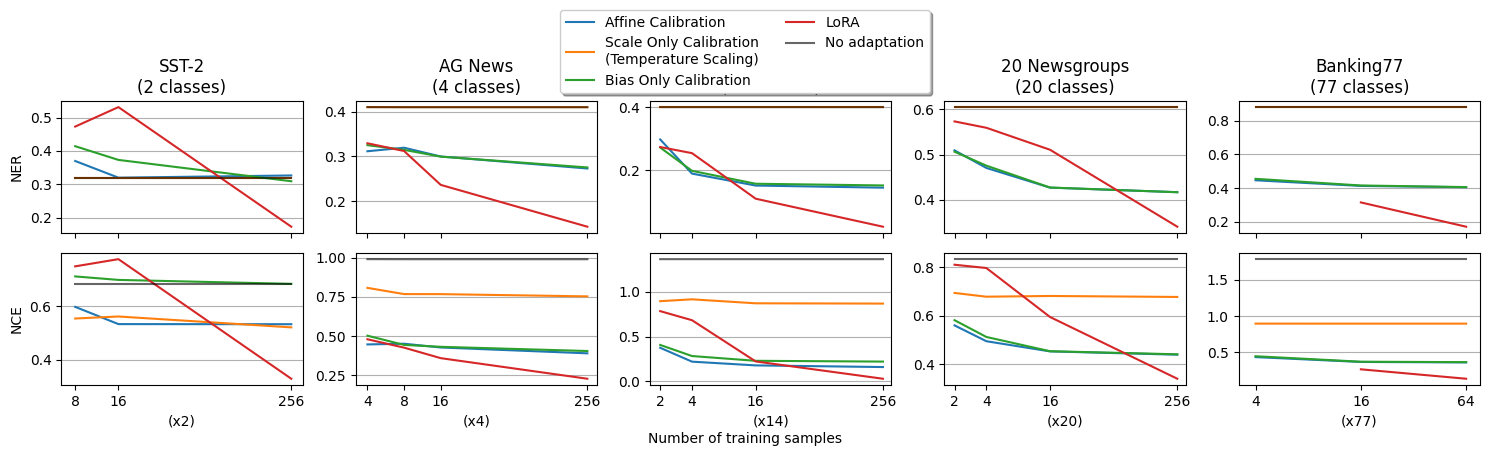

In [9]:
plot_results_for_model(df_results, "lm_tinyllama", metrics, width = 0.5)